# PS2 — Problem 3: Glosten–Milgrom Quote-Setter

Implement the rational zero-profit quote-setter as a **PyTorch belief update**.

**Setup:**
- Asset value $V \in \{V_L, V_H\}$ with prior $p = P(V = V_H)$
- Fraction $\mu$ of traders are *informed* (buy iff $V = V_H$, sell iff $V = V_L$)
- Fraction $(1-\mu)$ are *uninformed* (buy or sell with equal probability)

**Zero-profit quotes (Bayesian posteriors):**
$$\text{Ask} = E[V \mid \text{buy}] = P(V_H \mid \text{buy})\,V_H + P(V_L \mid \text{buy})\,V_L$$
$$\text{Bid} = E[V \mid \text{sell}] = P(V_H \mid \text{sell})\,V_H + P(V_L \mid \text{sell})\,V_L$$

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib

torch.manual_seed(99)
np.random.seed(99)

OUT_DIR = pathlib.Path("output"); OUT_DIR.mkdir(exist_ok=True)
FIG_DIR = pathlib.Path("figures"); FIG_DIR.mkdir(exist_ok=True)


## 1 · GM Belief Update (PyTorch)

In [2]:
def gm_quotes(p: torch.Tensor, mu: torch.Tensor,
              V_L: torch.Tensor, V_H: torch.Tensor
              ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Compute GM bid/ask and posterior beliefs.

    Parameters
    ----------
    p   : prior P(V = V_H), shape (*)
    mu  : fraction informed, scalar or broadcastable
    V_L : low asset value
    V_H : high asset value

    Returns
    -------
    ask, bid : zero-profit quotes
    p_after_buy, p_after_sell : updated beliefs
    """
    # Likelihoods
    # P(buy | V_H)  = mu*1 + (1-mu)*0.5 = (1 + mu) / 2
    # P(buy | V_L)  = mu*0 + (1-mu)*0.5 = (1 - mu) / 2
    # P(sell | V_H) = (1 - mu) / 2
    # P(sell | V_L) = (1 + mu) / 2
    lkh_buy_H  = (1 + mu) / 2
    lkh_buy_L  = (1 - mu) / 2
    lkh_sell_H = (1 - mu) / 2
    lkh_sell_L = (1 + mu) / 2

    # Marginal probabilities of a buy / sell
    p_buy  = p * lkh_buy_H  + (1 - p) * lkh_buy_L
    p_sell = p * lkh_sell_H + (1 - p) * lkh_sell_L

    # Posterior beliefs  (Bayes)
    p_VH_buy  = p * lkh_buy_H  / p_buy
    p_VH_sell = p * lkh_sell_H / p_sell

    # Zero-profit quotes
    ask = p_VH_buy  * V_H + (1 - p_VH_buy)  * V_L
    bid = p_VH_sell * V_H + (1 - p_VH_sell) * V_L

    return ask, bid, p_VH_buy, p_VH_sell


def gm_update(p: torch.Tensor, mu: torch.Tensor, direction: int) -> torch.Tensor:
    """Update belief after observing a trade. direction: +1 = buy, -1 = sell."""
    lkh_buy_H  = (1 + mu) / 2
    lkh_buy_L  = (1 - mu) / 2
    lkh_sell_H = (1 - mu) / 2
    lkh_sell_L = (1 + mu) / 2

    if direction == 1:   # buy
        num = p * lkh_buy_H
        den = p * lkh_buy_H + (1 - p) * lkh_buy_L
    else:                # sell
        num = p * lkh_sell_H
        den = p * lkh_sell_H + (1 - p) * lkh_sell_L

    return num / den


## 2 · Unit Test Against Hand-Computed Values

In [3]:
# ── Test parameters ──────────────────────────────────────────────────────────
# p=0.5 (symmetric prior), mu=0.3, V_L=90, V_H=110
# Hand computation:
#   P(buy|V_H) = (1+0.3)/2 = 0.65,  P(buy|V_L) = (1-0.3)/2 = 0.35
#   p_buy      = 0.5*0.65 + 0.5*0.35 = 0.50
#   P(V_H|buy) = 0.5*0.65 / 0.50    = 0.65
#   Ask        = 0.65*110 + 0.35*90  = 71.5 + 31.5 = 103.0
#
#   P(sell|V_H) = 0.35,  P(sell|V_L) = 0.65
#   p_sell      = 0.5*0.35 + 0.5*0.65 = 0.50
#   P(V_H|sell) = 0.5*0.35 / 0.50    = 0.35
#   Bid         = 0.35*110 + 0.65*90  = 38.5 + 58.5 = 97.0

p0   = torch.tensor(0.5)
mu0  = torch.tensor(0.3)
VL   = torch.tensor(90.0)
VH   = torch.tensor(110.0)

ask, bid, p_buy, p_sell = gm_quotes(p0, mu0, VL, VH)

HAND_ASK   = 103.0
HAND_BID   = 97.0
HAND_P_BUY = 0.65
HAND_P_SEL = 0.35

print("=" * 55)
print("Unit Test — p=0.5, μ=0.3, V_L=90, V_H=110")
print("=" * 55)
print(f"  Ask            : {ask.item():.4f}  (expected {HAND_ASK:.4f})")
print(f"  Bid            : {bid.item():.4f}  (expected {HAND_BID:.4f})")
print(f"  Spread         : {(ask-bid).item():.4f}")
print(f"  P(V_H|buy)     : {p_buy.item():.4f}  (expected {HAND_P_BUY:.4f})")
print(f"  P(V_H|sell)    : {p_sell.item():.4f}  (expected {HAND_P_SEL:.4f})")

tol = 1e-6
assert abs(ask.item()    - HAND_ASK)   < tol, f"Ask mismatch: {ask.item()}"
assert abs(bid.item()    - HAND_BID)   < tol, f"Bid mismatch: {bid.item()}"
assert abs(p_buy.item()  - HAND_P_BUY) < tol, f"P_buy mismatch: {p_buy.item()}"
assert abs(p_sell.item() - HAND_P_SEL) < tol, f"P_sell mismatch: {p_sell.item()}"
print()
print("All assertions PASSED ✓")


Unit Test — p=0.5, μ=0.3, V_L=90, V_H=110
  Ask            : 103.0000  (expected 103.0000)
  Bid            : 97.0000  (expected 97.0000)
  Spread         : 6.0000
  P(V_H|buy)     : 0.6500  (expected 0.6500)
  P(V_H|sell)    : 0.3500  (expected 0.3500)

All assertions PASSED ✓


## 3 · Belief Update After a Single Trade

In [4]:
# ── After one buy ────────────────────────────────────────────────────────────
p_post_buy  = gm_update(p0, mu0, direction=+1)
p_post_sell = gm_update(p0, mu0, direction=-1)

ask2, bid2, _, _ = gm_quotes(p_post_buy, mu0, VL, VH)

print("After one BUY  (true V_H scenario):")
print(f"  Prior p(V_H)        : {p0.item():.4f}")
print(f"  Posterior p(V_H)    : {p_post_buy.item():.4f}  (+{(p_post_buy-p0).item():.4f})")
print(f"  New Ask             : {ask2.item():.4f}")
print(f"  New Bid             : {bid2.item():.4f}")
print()

ask3, bid3, _, _ = gm_quotes(p_post_sell, mu0, VL, VH)
print("After one SELL (true V_L scenario):")
print(f"  Prior p(V_H)        : {p0.item():.4f}")
print(f"  Posterior p(V_H)    : {p_post_sell.item():.4f}  ({(p_post_sell-p0).item():.4f})")
print(f"  New Ask             : {ask3.item():.4f}")
print(f"  New Bid             : {bid3.item():.4f}")


After one BUY  (true V_H scenario):
  Prior p(V_H)        : 0.5000
  Posterior p(V_H)    : 0.6500  (+0.1500)
  New Ask             : 105.5046
  New Bid             : 100.0000

After one SELL (true V_L scenario):
  Prior p(V_H)        : 0.5000
  Posterior p(V_H)    : 0.3500  (-0.1500)
  New Ask             : 100.0000
  New Bid             : 94.4954


## 4 · Quote Sensitivity to μ (Informed-Trade Probability)

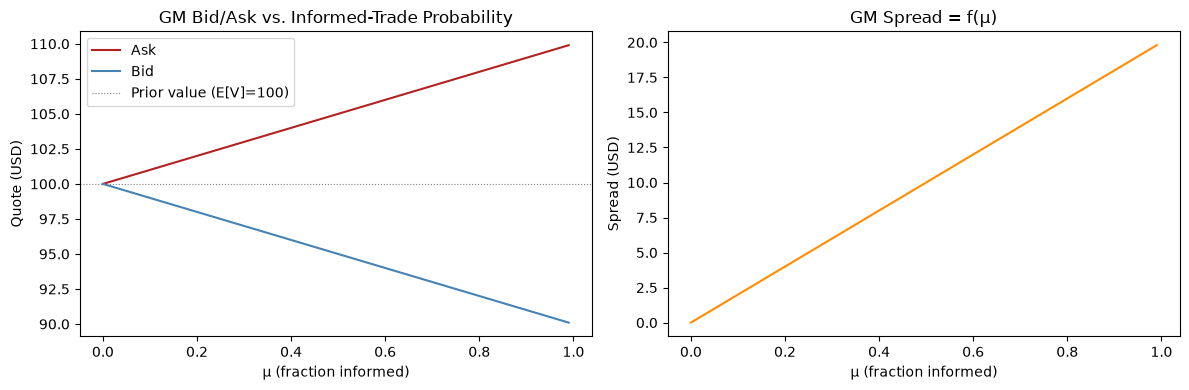

Quote widens as informed fraction μ → 1 (pure adverse selection)


In [5]:
mu_grid = torch.linspace(0.0, 0.99, 200)
asks, bids, spreads, midpoints = [], [], [], []

for mu_val in mu_grid:
    a, b, _, _ = gm_quotes(p0, mu_val, VL, VH)
    asks.append(a.item())
    bids.append(b.item())
    spreads.append((a - b).item())
    midpoints.append(((a + b) / 2).item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mu_grid.numpy(), asks,   label="Ask", color="firebrick")
axes[0].plot(mu_grid.numpy(), bids,   label="Bid", color="steelblue")
axes[0].axhline(100, ls=":", color="gray", lw=0.8, label="Prior value (E[V]=100)")
axes[0].set_xlabel("μ (fraction informed)")
axes[0].set_ylabel("Quote (USD)")
axes[0].set_title("GM Bid/Ask vs. Informed-Trade Probability")
axes[0].legend()

axes[1].plot(mu_grid.numpy(), spreads, color="darkorange")
axes[1].set_xlabel("μ (fraction informed)")
axes[1].set_ylabel("Spread (USD)")
axes[1].set_title("GM Spread = f(μ)")

plt.tight_layout()
plt.savefig(FIG_DIR / "ps2_p3_gm_sensitivity.png", dpi=150)
plt.show()
print("Quote widens as informed fraction μ → 1 (pure adverse selection)")


## 5 · Export

In [6]:
rows = []
for mu_val, a, b, s in zip(mu_grid.numpy(), asks, bids, spreads):
    rows.append({"mu": mu_val, "ask": a, "bid": b, "spread": s})

pd.DataFrame(rows).to_csv(OUT_DIR / "ps2_p3_gm_sensitivity.csv", index=False)
print("Saved output/ps2_p3_gm_sensitivity.csv")

print()
print("Summary at μ=0.3, p=0.5, V_L=90, V_H=110:")
print(f"  Ask = {ask.item():.4f} USD")
print(f"  Bid = {bid.item():.4f} USD")
print(f"  Spread = {(ask-bid).item():.4f} USD  (adverse-selection premium)")
print(f"  Mid    = {((ask+bid)/2).item():.4f} USD  (= prior E[V] when p=0.5, symmetric)")


Saved output/ps2_p3_gm_sensitivity.csv

Summary at μ=0.3, p=0.5, V_L=90, V_H=110:
  Ask = 103.0000 USD
  Bid = 97.0000 USD
  Spread = 6.0000 USD  (adverse-selection premium)
  Mid    = 100.0000 USD  (= prior E[V] when p=0.5, symmetric)
